<a href="https://colab.research.google.com/github/UNSW-ZZSC9020/project/blob/main/src/GoogleColab.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Welcome to ZZSC9020

This Python notebook shows how to clone the course GitHub repository on Google Colab.

You can develop your data analysis on Google Colab without downloading the data to your computer.

In [6]:
#clone
!rm -rf zzsc9020-teamc data
!git clone https://github.com/t-frank-unsw/zzsc9020-teamc.git
#check files
!ls -la zzsc9020-teamc/data/NSW/
#make folder
!mkdir -p data
!cat zzsc9020-teamc/data/NSW/forecastdemand_nsw.csv.zip.part* > data/forecastdemand_nsw.csv.zip
#unzip files
!unzip data/forecastdemand_nsw.csv.zip -d data
!unzip zzsc9020-teamc/data/NSW/temperature_nsw.csv.zip -d data
!unzip zzsc9020-teamc/data/NSW/totaldemand_nsw.csv.zip -d data
#clean
!rm data/forecastdemand_nsw.csv.zip
#check
!ls -lh data/

Cloning into 'zzsc9020-teamc'...
remote: Enumerating objects: 180, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 180 (delta 40), reused 30 (delta 18), pack-reused 113 (from 4)
Receiving objects: 100% (180/180), 207.26 MiB | 31.33 MiB/s, done.
Resolving deltas: 100% (53/53), done.
Updating files: 100% (22/22), done.
total 118904
drwxr-xr-x 2 root root      4096 Sep 21 20:42 .
drwxr-xr-x 3 root root      4096 Sep 21 20:42 ..
-rw-r--r-- 1 root root 104857600 Sep 21 20:42 forecastdemand_nsw.csv.zip.partaa
-rw-r--r-- 1 root root  14669007 Sep 21 20:42 forecastdemand_nsw.csv.zip.partab
-rw-r--r-- 1 root root    920562 Sep 21 20:42 temperature_nsw.csv.zip
-rw-r--r-- 1 root root   1296200 Sep 21 20:42 totaldemand_nsw.csv.zip
Archive:  data/forecastdemand_nsw.csv.zip
  inflating: data/forecastdemand_nsw.csv  
Archive:  zzsc9020-teamc/data/NSW/temperature_nsw.csv.zip
  inflating: data/temperature_nsw.csv  
Archive:  zzsc9020-te

In [7]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

PATH_FORECAST = "data/forecastdemand_nsw.csv"
PATH_TEMP     = "data/temperature_nsw.csv"
PATH_ACTUAL   = "data/totaldemand_nsw.csv"

def dt_dayfirst(s):
    return pd.to_datetime(s, errors="coerce", dayfirst=True, infer_datetime_format=True)

def dt_us(s):
    s = s.astype(str).str.strip().str.replace(r"(\d{1,2})/(\d{1,2})/(\d{2})(?!\d)", r"\1/\2/20\3", regex=True)
    return pd.to_datetime(s, errors="coerce", dayfirst=False, infer_datetime_format=True)

#daily actual peak
a = (pd.read_csv(PATH_ACTUAL, usecols=["DATETIME","TOTALDEMAND","REGIONID"])
      .query("REGIONID=='NSW1'").drop(columns="REGIONID"))
a["DATETIME"] = dt_dayfirst(a["DATETIME"])
a["ACTUAL"] = pd.to_numeric(a["TOTALDEMAND"], errors="coerce")
a = a.dropna(subset=["DATETIME","ACTUAL"])
a["DATE"] = a["DATETIME"].dt.floor("D")
daily_actual = a.groupby("DATE", as_index=False)["ACTUAL"].max().rename(columns={"ACTUAL":"ACTUAL_PEAK"})

#daily max and min temp
t = pd.read_csv(PATH_TEMP).rename(columns={"TemperatureTEMPERATURE":"TEMPERATURE"})
t["DATETIME"] = dt_dayfirst(t["DATETIME"])
t["TEMPERATURE"] = pd.to_numeric(t["TEMPERATURE"], errors="coerce")
t = t.dropna(subset=["DATETIME","TEMPERATURE"])
t["DATE"] = t["DATETIME"].dt.floor("D")
daily_temp = t.groupby("DATE", as_index=False)["TEMPERATURE"].agg({
    "TEMP_MAX": "max",
    "TEMP_MIN": "min"
})

#forecast max energy demand from day before
f = (pd.read_csv(PATH_FORECAST, usecols=["DATETIME","FORECASTDEMAND","REGIONID","LASTCHANGED"])
      .query("REGIONID=='NSW1'").drop(columns="REGIONID"))
f["DATETIME"]    = dt_us(f["DATETIME"])
f["LASTCHANGED"] = dt_us(f["LASTCHANGED"])
f["FORECASTDEMAND"] = pd.to_numeric(f["FORECASTDEMAND"], errors="coerce")
f = f.dropna(subset=["DATETIME","LASTCHANGED","FORECASTDEMAND"])
f["DATE_TARGET"] = f["DATETIME"].dt.floor("D")
f["DATE_ISSUE"]  = f["LASTCHANGED"].dt.floor("D")
f_day_ahead = f.loc[f["DATE_ISSUE"].eq(f["DATE_TARGET"] - pd.Timedelta(days=1))]
daily_forecast = (f_day_ahead.groupby("DATE_TARGET", as_index=False)["FORECASTDEMAND"]
                  .max().rename(columns={"DATE_TARGET":"DATE","FORECASTDEMAND":"FORECAST_PEAK_24H"}))

#merge
daily = (daily_actual.merge(daily_temp, on="DATE", how="left")
                     .merge(daily_forecast, on="DATE", how="left"))
daily["ERROR"] = daily["ACTUAL_PEAK"] - daily["FORECAST_PEAK_24H"]
daily["YEAR"]  = daily["DATE"].dt.year

#add extreme temperature flags
daily["EXTREME_HOT"] = (daily["TEMP_MAX"] > 35).astype(int)   #extreme hot day = max temp > 35 deg C
daily["EXTREME_COLD"] = (daily["TEMP_MIN"] < 5).astype(int)   #extreme cold day = min temp < 5 deg C
daily["TEMP_EXTREME"] = ((daily["EXTREME_HOT"] == 1) | (daily["EXTREME_COLD"] == 1)).astype(int)

In [8]:
daily.head()

,DATE,ACTUAL_PEAK,TEMP_MAX,TEMP_MIN,FORECAST_PEAK_24H,ERROR,YEAR,EXTREME_HOT,EXTREME_COLD,TEMP_EXTREME
0,2010-01-01,8883.98,28.8,22.1,9203.56,-319.58,2010,0,0,0
1,2010-01-02,9294.07,29.4,21.6,9035.95,258.12,2010,0,0,0
2,2010-01-03,8247.61,21.5,17.9,8427.68,-180.07,2010,0,0,0
3,2010-01-04,9468.92,23.9,17.9,10200.10,-731.18,2010,0,0,0
4,2010-01-05,10687.29,27.7,15.4,10750.37,-63.08,2010,0,0,0


Max Temperature Analysis:


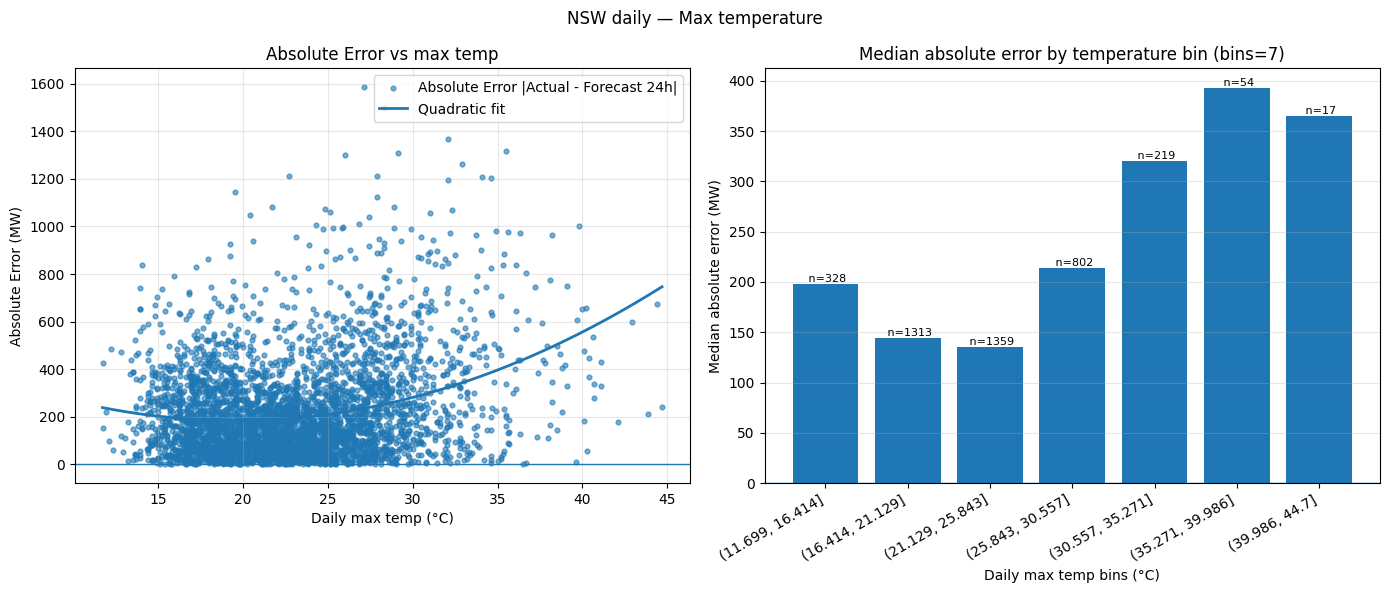


Min Temperature Analysis:


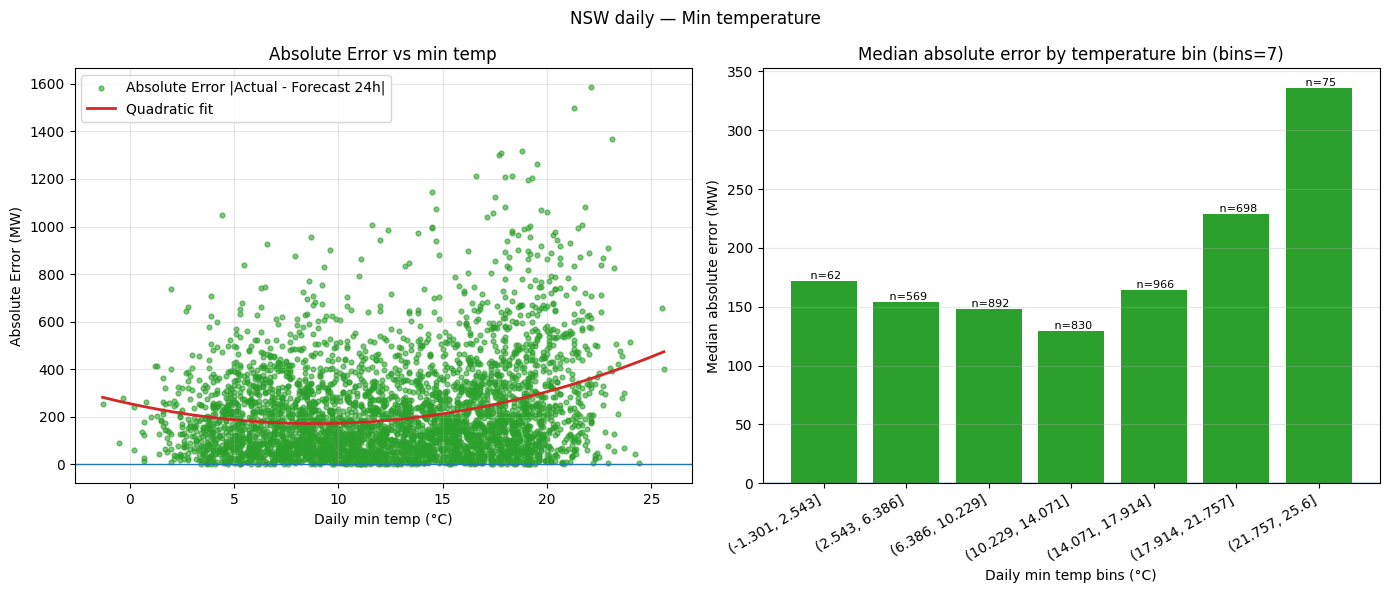

In [9]:
#plot functions for max and min temperature - see how day before forecast performed at different max/min temperature days
def _quad_fit(x, y, n=200):
    x, y = np.asarray(x, float), np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3: return np.array([]), np.array([])
    xm, xs = x[m].mean(), (x[m].std() or 1.0)
    coef = np.polyfit((x[m]-xm)/xs, y[m], deg=2)
    xg = np.linspace(x[m].min(), x[m].max(), n)
    return xg, np.polyval(coef, (xg-xm)/xs)

def plot_error_views_max_temp(d, year=None, bins=7):
    d = d.loc[d["YEAR"].eq(year)] if year is not None else d
    d = d.dropna(subset=["TEMP_MAX","ERROR"]).copy()
    if d.empty: return
    x, e = d["TEMP_MAX"].to_numpy(), np.abs(d["ERROR"].to_numpy())
    xg, e_fit = _quad_fit(x, e)

    fig, axs = plt.subplots(1,2, figsize=(14,6))
    axs[0].axhline(0, linewidth=1)
    axs[0].scatter(x, e, alpha=0.6, s=12, label="Absolute Error |Actual - Forecast 24h|")
    if xg.size: axs[0].plot(xg, e_fit, linewidth=2, label="Quadratic fit")
    axs[0].set_xlabel("Daily max temp (°C)"); axs[0].set_ylabel("Absolute Error (MW)")
    axs[0].set_title("Absolute Error vs max temp"); axs[0].legend(); axs[0].grid(True, alpha=0.3)

    edges = np.linspace(d["TEMP_MAX"].min(), d["TEMP_MAX"].max(), bins+1)
    d = d.assign(TEMP_BIN=pd.cut(d["TEMP_MAX"], bins=edges, include_lowest=True),
                 ABS_ERROR=np.abs(d["ERROR"]))
    g = d.groupby("TEMP_BIN", observed=True).agg(mean_error=("ABS_ERROR","median"),
                                                 count=("ABS_ERROR","size")).reset_index()

    axs[1].bar(np.arange(len(g)), g["mean_error"])
    axs[1].axhline(0, linewidth=1)
    axs[1].set_xticks(np.arange(len(g))); axs[1].set_xticklabels(g["TEMP_BIN"].astype(str), rotation=30, ha="right")
    axs[1].set_xlabel("Daily max temp bins (°C)"); axs[1].set_ylabel("Median absolute error (MW)")
    axs[1].set_title(f"Median absolute error by temperature bin (bins={bins})")
    for i, (val, cnt) in enumerate(zip(g["mean_error"], g["count"])):
        axs[1].text(i, val, f" n={cnt}", ha="center", va="bottom", fontsize=8)
    axs[1].grid(True, axis="y", alpha=0.3)
    plt.suptitle(f"NSW daily — Max temperature{' ('+str(year)+')' if year else ''}")
    plt.tight_layout(); plt.show()

def plot_error_views_min_temp(d, year=None, bins=7):
    d = d.loc[d["YEAR"].eq(year)] if year is not None else d
    d = d.dropna(subset=["TEMP_MIN","ERROR"]).copy()
    if d.empty: return
    x, e = d["TEMP_MIN"].to_numpy(), np.abs(d["ERROR"].to_numpy())
    xg, e_fit = _quad_fit(x, e)

    fig, axs = plt.subplots(1,2, figsize=(14,6))
    axs[0].axhline(0, linewidth=1)
    axs[0].scatter(x, e, alpha=0.6, s=12, label="Absolute Error |Actual - Forecast 24h|", color="C2")
    if xg.size: axs[0].plot(xg, e_fit, linewidth=2, label="Quadratic fit", color="C3")
    axs[0].set_xlabel("Daily min temp (°C)"); axs[0].set_ylabel("Absolute Error (MW)")
    axs[0].set_title("Absolute Error vs min temp"); axs[0].legend(); axs[0].grid(True, alpha=0.3)

    edges = np.linspace(d["TEMP_MIN"].min(), d["TEMP_MIN"].max(), bins+1)
    d = d.assign(TEMP_BIN=pd.cut(d["TEMP_MIN"], bins=edges, include_lowest=True),
                 ABS_ERROR=np.abs(d["ERROR"]))
    g = d.groupby("TEMP_BIN", observed=True).agg(mean_error=("ABS_ERROR","median"),
                                                 count=("ABS_ERROR","size")).reset_index()

    axs[1].bar(np.arange(len(g)), g["mean_error"], color="C2")
    axs[1].axhline(0, linewidth=1)
    axs[1].set_xticks(np.arange(len(g))); axs[1].set_xticklabels(g["TEMP_BIN"].astype(str), rotation=30, ha="right")
    axs[1].set_xlabel("Daily min temp bins (°C)"); axs[1].set_ylabel("Median absolute error (MW)")
    axs[1].set_title(f"Median absolute error by temperature bin (bins={bins})")
    for i, (val, cnt) in enumerate(zip(g["mean_error"], g["count"])):
        axs[1].text(i, val, f" n={cnt}", ha="center", va="bottom", fontsize=8)
    axs[1].grid(True, axis="y", alpha=0.3)
    plt.suptitle(f"NSW daily — Min temperature{' ('+str(year)+')' if year else ''}")
    plt.tight_layout(); plt.show()

#call functions
print("Max Temperature Analysis:")
plot_error_views_max_temp(daily)
print("\nMin Temperature Analysis:")
plot_error_views_min_temp(daily)

Fitting 4 folds for each of 20 candidates, totalling 80 fits
Best params: {'n_estimators': 400, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 16}
Forecast (24h) on ALL data: {'MAE': 216.4398337001712, 'RMSE': 293.2432346091219, 'MAPE_pct': np.float64(2.23760666693388), 'R2': 0.9401868862073843}
RandomForest on ALL data: {'MAE': 103.35560437663572, 'RMSE': 153.5650213654516, 'MAPE_pct': np.float64(1.0745815099448424), 'R2': 0.9835969345354356}

MAE improvement: 113.1 MW (52.2%)
RMSE improvement: 139.7 MW (47.6%)
R² improvement: 0.043 (4.6%)
Max Temperature Analysis:


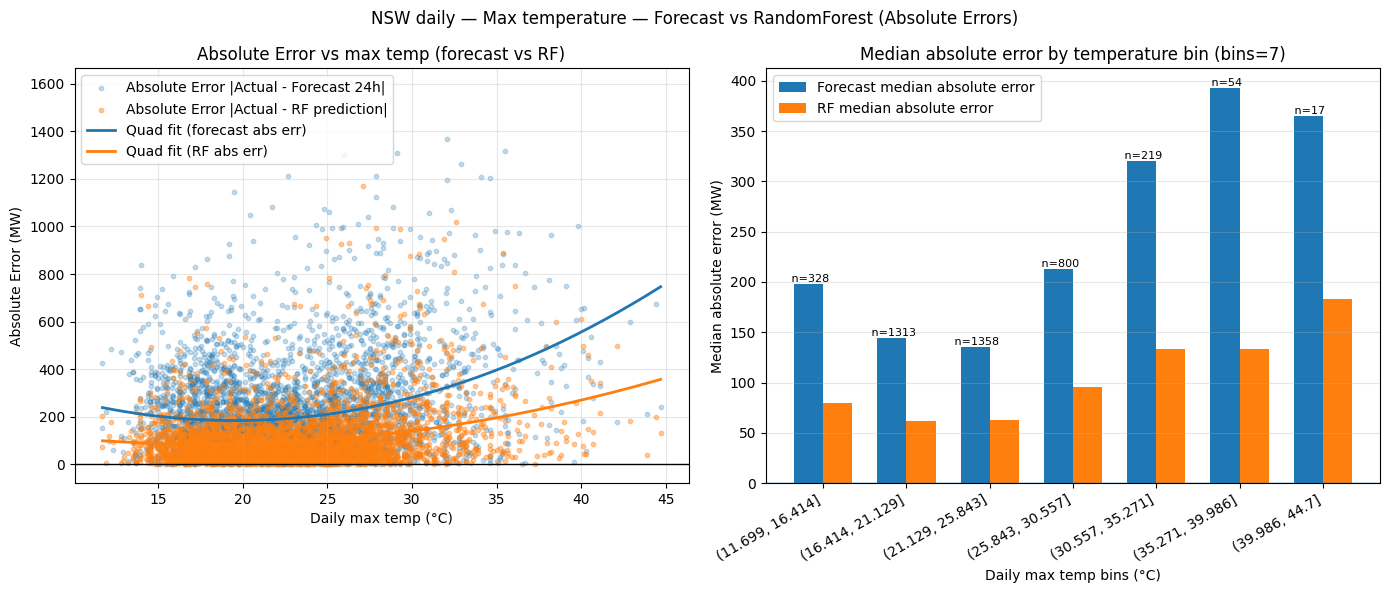


Min Temperature Analysis:


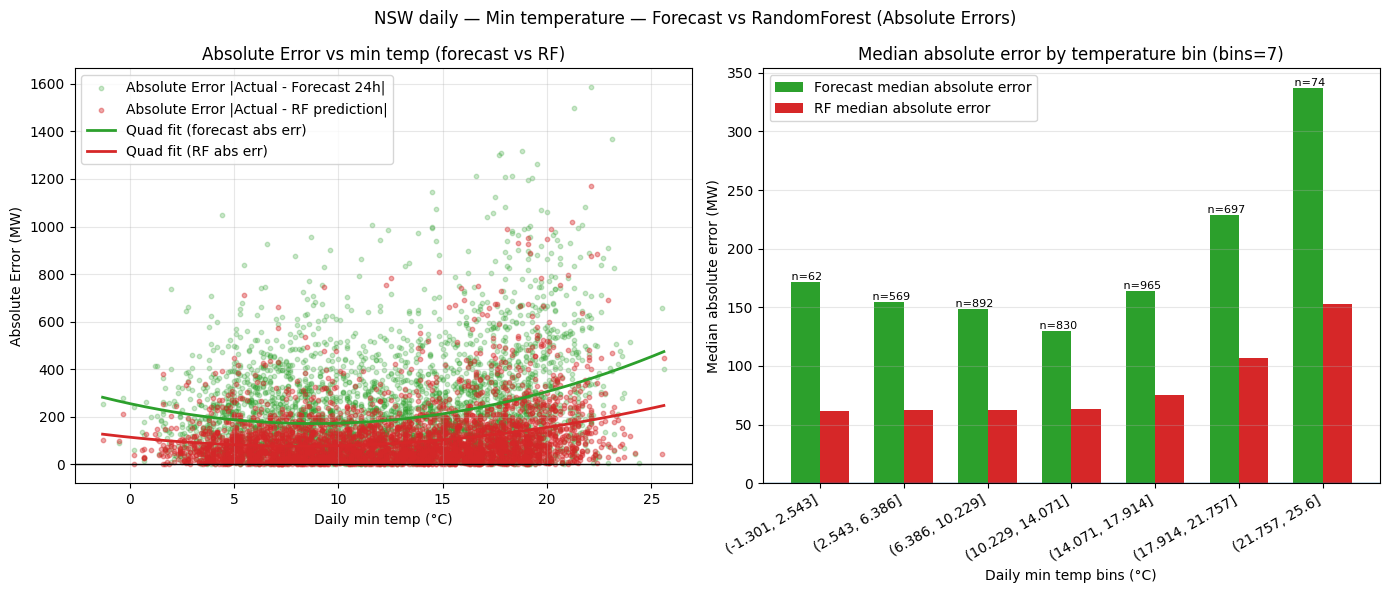


Extreme Weather Conditions Analysis:


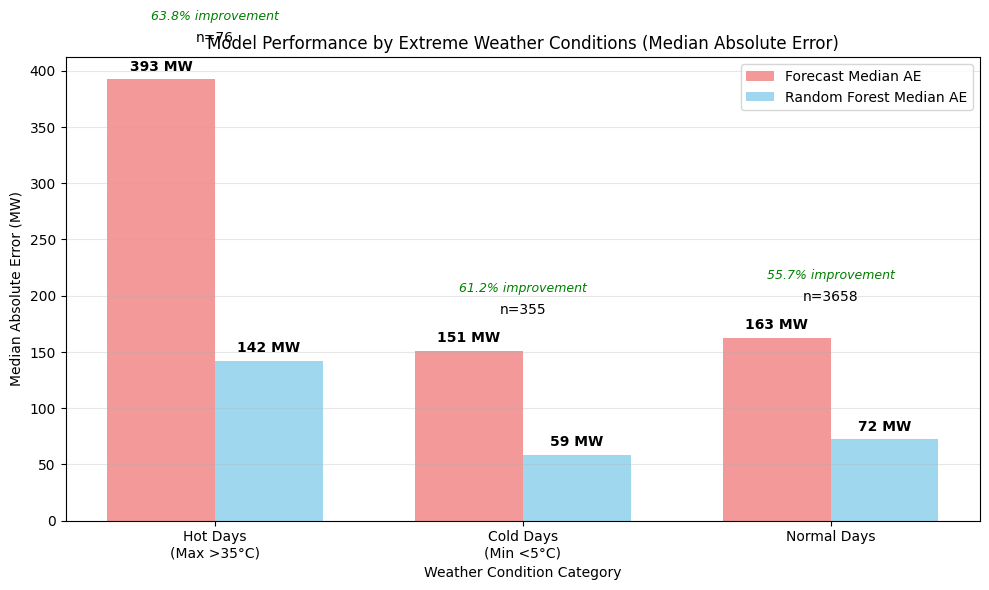


Extreme Weather Performance Summary (Median Absolute Error):
Hot Days
(Max >35°C): 76 days, Forecast: 392.7 MW, RF: 142.1 MW, Improvement: 63.8%
Cold Days
(Min <5°C): 355 days, Forecast: 151.1 MW, RF: 58.7 MW, Improvement: 61.2%
Normal Days: 3658 days, Forecast: 162.6 MW, RF: 72.1 MW, Improvement: 55.7%
Feature importances (top 15):
FORECAST_PEAK_24H    0.648866
FORECAST_lag1        0.137699
FORECAST_roll3       0.061920
TEMP_MAX             0.058447
TEMP_EXTREME         0.019938
EXTREME_HOT          0.015696
DOY_cos              0.009343
TEMP_MIN             0.006368
TEMP_MAX_roll3       0.005949
DOY_sin              0.005162
TEMP_RANGE           0.004480
TEMP_MAX_lag1        0.004465
TEMP_MIN_lag1        0.003642
TEMP_MAX_lag2        0.003578
TEMP_MAX_lag3        0.003069
dtype: float64

Improvement by temperature extremes:
Hot days (max >35°C): {'n': 76, 'forecast_MAE': 412.73315789473685, 'forecast_R2': 0.8472073067467959, 'rf_MAE': 199.80371865676597, 'rf_R2': 0.9564530272559607,

In [12]:
#random forest model to predict daily peak demand from TEMP_MAX/MIN + other features

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import math
import warnings
warnings.filterwarnings("ignore")
RSEED = 42

#prep features
d = daily.copy().sort_values("DATE").reset_index(drop=True)
#drop rows with missing target, TEMP_MAX, or TEMP_MIN
d = d.dropna(subset=["ACTUAL_PEAK","TEMP_MAX","TEMP_MIN"]).reset_index(drop=True)

#feature engineering
d["FORECAST_PEAK_24H"] = d["FORECAST_PEAK_24H"].fillna(method="ffill").fillna(d["ACTUAL_PEAK"].median())
#calendar features
d["DOY"] = d["DATE"].dt.dayofyear
#cyclical encoding for day of year
d["DOY_sin"] = np.sin(2*np.pi * d["DOY"]/365.25)
d["DOY_cos"] = np.cos(2*np.pi * d["DOY"]/365.25)
d["YEAR"] = d["DATE"].dt.year

#temperature range
d["TEMP_RANGE"] = d["TEMP_MAX"] - d["TEMP_MIN"]

#lags & rolling stats on TEMP_MAX, TEMP_MIN and forecasts
for lag in [1,2,3]:
    d[f"TEMP_MAX_lag{lag}"] = d["TEMP_MAX"].shift(lag)
    d[f"TEMP_MIN_lag{lag}"] = d["TEMP_MIN"].shift(lag)
    d[f"FORECAST_lag{lag}"] = d["FORECAST_PEAK_24H"].shift(lag)

#rolling mean of previous 3 days
d["TEMP_MAX_roll3"] = d["TEMP_MAX"].shift(1).rolling(3, min_periods=1).mean()
d["TEMP_MIN_roll3"] = d["TEMP_MIN"].shift(1).rolling(3, min_periods=1).mean()
d["FORECAST_roll3"]  = d["FORECAST_PEAK_24H"].shift(1).rolling(3, min_periods=1).mean()

#target variable (actual_peak = peak energy demand on a day)
d = d.dropna().reset_index(drop=True)  # drop rows with any NA from lags
y = d["ACTUAL_PEAK"].values

#features included in model
features = [
    "TEMP_MAX","TEMP_MIN","TEMP_RANGE",
    "TEMP_MAX_roll3","TEMP_MIN_roll3",
    "TEMP_MAX_lag1","TEMP_MAX_lag2","TEMP_MAX_lag3",
    "TEMP_MIN_lag1","TEMP_MIN_lag2","TEMP_MIN_lag3",
    "FORECAST_PEAK_24H","FORECAST_roll3","FORECAST_lag1",
    "DOY_sin","DOY_cos","YEAR","TEMP_EXTREME","EXTREME_HOT","EXTREME_COLD"
]
X = d[features].astype(float)

#train/test split
n = len(d)
test_size = int(math.ceil(n * 0.20))
train_idx = np.arange(0, n - test_size)
test_idx  = np.arange(n - test_size, n)

X_train, y_train = X.iloc[train_idx], y[train_idx]
X_test,  y_test  = X.iloc[test_idx],  y[test_idx]

#sample weights to focus the model on extremes - upweight extreme temps
alpha = 3.0
temp_med = X_train["TEMP_MAX"].median()
temp_iqr = (X_train["TEMP_MAX"].quantile(0.75) - X_train["TEMP_MAX"].quantile(0.25)) or 1.0
#distance measure
dist = np.abs(X_train["TEMP_MAX"] - temp_med) / temp_iqr
sample_weight = 1.0 + alpha * (dist / (dist.max() if dist.max()>0 else 1.0))
#ensure extremes flagged strongly
sample_weight = sample_weight * (1.0 + 2.0 * X_train["TEMP_EXTREME"])

#random Forest with randomized search
rf = RandomForestRegressor(random_state=RSEED, n_jobs=-1)
param_dist = {
    "n_estimators": [200, 400, 800],
    "max_depth": [6, 10, 16, None],
    "min_samples_leaf": [1,2,4,8],
    "max_features": ["auto","sqrt",0.5]
}
tscv = TimeSeriesSplit(n_splits=4)
rs = RandomizedSearchCV(
    rf, param_distributions=param_dist, n_iter=20,
    cv=tscv, scoring="neg_mean_absolute_error", random_state=RSEED, n_jobs=-1, verbose=1
)

rs.fit(X_train, y_train, sample_weight=sample_weight.values)
best = rs.best_estimator_
print("Best params:", rs.best_params_)

#predict
pred_train = best.predict(X_train)
pred_test  = best.predict(X_test)
pred_all   = best.predict(X)

#attach predictions and residuals to d
d["PRED_RF"] = pred_all
d["RESID_RF"] = d["ACTUAL_PEAK"] - d["PRED_RF"]
d["RESID_FORECAST"] = d["ACTUAL_PEAK"] - d["FORECAST_PEAK_24H"]

#metrics to measure model effectiveness (mae, rmse)
def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    #r squared
    r2 = r2_score(y_true, y_pred)
    return {"MAE":mae, "RMSE":rmse, "MAPE_pct":mape, "R2":r2}

metrics_forecast_test = metrics(d["ACTUAL_PEAK"].values, d["FORECAST_PEAK_24H"].values)
metrics_rf_test = metrics(d["ACTUAL_PEAK"].values, d["PRED_RF"].values)
print("Forecast (24h) on ALL data:", metrics_forecast_test)
print("RandomForest on ALL data:", metrics_rf_test)

#calculate improvement
mae_improvement = metrics_forecast_test["MAE"] - metrics_rf_test["MAE"]
rmse_improvement = metrics_forecast_test["RMSE"] - metrics_rf_test["RMSE"]
r2_improvement = metrics_rf_test["R2"] - metrics_forecast_test["R2"]
print(f"\nMAE improvement: {mae_improvement:.1f} MW ({mae_improvement/metrics_forecast_test['MAE']*100:.1f}%)")
print(f"RMSE improvement: {rmse_improvement:.1f} MW ({rmse_improvement/metrics_forecast_test['RMSE']*100:.1f}%)")
print(f"R² improvement: {r2_improvement:.3f} ({r2_improvement/metrics_forecast_test['R2']*100:.1f}%)")

#plot comparison functions for both max and min temperature
#max temp plots
def plot_compare_rf_max_temp(dframe, year=None, bins=7):
    dd = dframe.loc[dframe["YEAR"].eq(year)] if year is not None else dframe
    dd = dd.dropna(subset=["TEMP_MAX","RESID_FORECAST","RESID_RF"]).copy()
    if dd.empty:
        print("No data")
        return

    x = dd["TEMP_MAX"].to_numpy()
    e_fc = np.abs(dd["RESID_FORECAST"].to_numpy())
    e_rf = np.abs(dd["RESID_RF"].to_numpy())

    def quad_fit(x, y, n=200):
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 3: return np.array([]), np.array([])
        xm, xs = x[m].mean(), (x[m].std() or 1.0)
        coef = np.polyfit((x[m]-xm)/xs, y[m], deg=2)
        xg = np.linspace(x[m].min(), x[m].max(), n)
        return xg, np.polyval(coef, (xg-xm)/xs)

    xg_fc, e_fit_fc = quad_fit(x, e_fc)
    xg_rf, e_fit_rf = quad_fit(x, e_rf)

    fig, axs = plt.subplots(1,2, figsize=(14,6))

    axs[0].axhline(0, linewidth=1, color="k")
    axs[0].scatter(x, e_fc, alpha=0.25, s=10, label="Absolute Error |Actual - Forecast 24h|", color="C0")
    axs[0].scatter(x, e_rf, alpha=0.4, s=10, label="Absolute Error |Actual - RF prediction|", color="C1")
    if xg_fc.size: axs[0].plot(xg_fc, e_fit_fc, linewidth=2, color="C0", label="Quad fit (forecast abs err)")
    if xg_rf.size: axs[0].plot(xg_rf, e_fit_rf, linewidth=2, color="C1", label="Quad fit (RF abs err)")
    axs[0].set_xlabel("Daily max temp (°C)"); axs[0].set_ylabel("Absolute Error (MW)")
    axs[0].set_title("Absolute Error vs max temp (forecast vs RF)")
    axs[0].legend(); axs[0].grid(True, alpha=0.3)

    edges = np.linspace(dd["TEMP_MAX"].min(), dd["TEMP_MAX"].max(), bins+1)
    dd = dd.assign(TEMP_BIN=pd.cut(dd["TEMP_MAX"], bins=edges, include_lowest=True),
                   ABS_RESID_FORECAST=np.abs(dd["RESID_FORECAST"]),
                   ABS_RESID_RF=np.abs(dd["RESID_RF"]))
    g_fc = dd.groupby("TEMP_BIN", observed=True).agg(med_err_fc=("ABS_RESID_FORECAST","median"),
                                                     count=("ABS_RESID_FORECAST","size")).reset_index()
    g_rf = dd.groupby("TEMP_BIN", observed=True).agg(med_err_rf=("ABS_RESID_RF","median")).reset_index()

    g = g_fc.merge(g_rf, on="TEMP_BIN")
    idx = np.arange(len(g))
    width = 0.35
    axs[1].bar(idx - width/2, g["med_err_fc"], width=width, label="Forecast median absolute error")
    axs[1].bar(idx + width/2, g["med_err_rf"], width=width, label="RF median absolute error")
    axs[1].axhline(0, linewidth=1)
    axs[1].set_xticks(idx); axs[1].set_xticklabels(g["TEMP_BIN"].astype(str), rotation=30, ha="right")
    axs[1].set_xlabel("Daily max temp bins (°C)"); axs[1].set_ylabel("Median absolute error (MW)")
    axs[1].set_title(f"Median absolute error by temperature bin (bins={bins})")
    for i, (fcv, rfv, cnt) in enumerate(zip(g["med_err_fc"], g["med_err_rf"], g["count"])):
        axs[1].text(i - width/2, fcv, f" n={cnt}", ha="center", va="bottom", fontsize=8)
    axs[1].legend(); axs[1].grid(True, axis="y", alpha=0.3)

    plt.suptitle(f"NSW daily — Max temperature{' ('+str(year)+')' if year else ''} — Forecast vs RandomForest (Absolute Errors)")
    plt.tight_layout(); plt.show()

#min temp plots
def plot_compare_rf_min_temp(dframe, year=None, bins=7):
    dd = dframe.loc[dframe["YEAR"].eq(year)] if year is not None else dframe
    dd = dd.dropna(subset=["TEMP_MIN","RESID_FORECAST","RESID_RF"]).copy()
    if dd.empty:
        print("No data")
        return

    x = dd["TEMP_MIN"].to_numpy()
    e_fc = np.abs(dd["RESID_FORECAST"].to_numpy())
    e_rf = np.abs(dd["RESID_RF"].to_numpy())

    def quad_fit(x, y, n=200):
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 3: return np.array([]), np.array([])
        xm, xs = x[m].mean(), (x[m].std() or 1.0)
        coef = np.polyfit((x[m]-xm)/xs, y[m], deg=2)
        xg = np.linspace(x[m].min(), x[m].max(), n)
        return xg, np.polyval(coef, (xg-xm)/xs)

    xg_fc, e_fit_fc = quad_fit(x, e_fc)
    xg_rf, e_fit_rf = quad_fit(x, e_rf)

    fig, axs = plt.subplots(1,2, figsize=(14,6))

    axs[0].axhline(0, linewidth=1, color="k")
    axs[0].scatter(x, e_fc, alpha=0.25, s=10, label="Absolute Error |Actual - Forecast 24h|", color="C2")
    axs[0].scatter(x, e_rf, alpha=0.4, s=10, label="Absolute Error |Actual - RF prediction|", color="C3")
    if xg_fc.size: axs[0].plot(xg_fc, e_fit_fc, linewidth=2, color="C2", label="Quad fit (forecast abs err)")
    if xg_rf.size: axs[0].plot(xg_rf, e_fit_rf, linewidth=2, color="C3", label="Quad fit (RF abs err)")
    axs[0].set_xlabel("Daily min temp (°C)"); axs[0].set_ylabel("Absolute Error (MW)")
    axs[0].set_title("Absolute Error vs min temp (forecast vs RF)")
    axs[0].legend(); axs[0].grid(True, alpha=0.3)

    edges = np.linspace(dd["TEMP_MIN"].min(), dd["TEMP_MIN"].max(), bins+1)
    dd = dd.assign(TEMP_BIN=pd.cut(dd["TEMP_MIN"], bins=edges, include_lowest=True),
                   ABS_RESID_FORECAST=np.abs(dd["RESID_FORECAST"]),
                   ABS_RESID_RF=np.abs(dd["RESID_RF"]))
    g_fc = dd.groupby("TEMP_BIN", observed=True).agg(med_err_fc=("ABS_RESID_FORECAST","median"),
                                                     count=("ABS_RESID_FORECAST","size")).reset_index()
    g_rf = dd.groupby("TEMP_BIN", observed=True).agg(med_err_rf=("ABS_RESID_RF","median")).reset_index()

    g = g_fc.merge(g_rf, on="TEMP_BIN")
    idx = np.arange(len(g))
    width = 0.35
    axs[1].bar(idx - width/2, g["med_err_fc"], width=width, label="Forecast median absolute error", color="C2")
    axs[1].bar(idx + width/2, g["med_err_rf"], width=width, label="RF median absolute error", color="C3")
    axs[1].axhline(0, linewidth=1)
    axs[1].set_xticks(idx); axs[1].set_xticklabels(g["TEMP_BIN"].astype(str), rotation=30, ha="right")
    axs[1].set_xlabel("Daily min temp bins (°C)"); axs[1].set_ylabel("Median absolute error (MW)")
    axs[1].set_title(f"Median absolute error by temperature bin (bins={bins})")
    for i, (fcv, rfv, cnt) in enumerate(zip(g["med_err_fc"], g["med_err_rf"], g["count"])):
        axs[1].text(i - width/2, fcv, f" n={cnt}", ha="center", va="bottom", fontsize=8)
    axs[1].legend(); axs[1].grid(True, axis="y", alpha=0.3)

    plt.suptitle(f"NSW daily — Min temperature{' ('+str(year)+')' if year else ''} — Forecast vs RandomForest (Absolute Errors)")
    plt.tight_layout(); plt.show()

#extreme weather performance plot to measure effectiveness of model on extreme hot day and extreme cold day
def plot_extreme_weather_performance(dframe):
    """Plot performance specifically for extreme hot and cold days using MEDIAN"""

    # Filter data
    hot_days = dframe.loc[dframe["EXTREME_HOT"] == 1]  #extreme hot day = max temp > 35 deg C
    cold_days = dframe.loc[dframe["EXTREME_COLD"] == 1]  #extreme cold day = min temp < 5 deg C
    normal_days = dframe.loc[(dframe["EXTREME_HOT"] == 0) & (dframe["EXTREME_COLD"] == 0)]

    def get_median_ae(subset, pred_col):
        if len(subset) == 0:
            return 0, 0
        median_ae = np.median(np.abs(subset["ACTUAL_PEAK"] - subset[pred_col]))
        return median_ae, len(subset)

    #calc mae
    categories = ['Hot Days\n(Max >35°C)', 'Cold Days\n(Min <5°C)', 'Normal Days']
    datasets = [hot_days, cold_days, normal_days]

    forecast_medians = []
    rf_medians = []
    sample_sizes = []

    for dataset in datasets:
        fc_median, n = get_median_ae(dataset, "FORECAST_PEAK_24H")
        rf_median, _ = get_median_ae(dataset, "PRED_RF")
        forecast_medians.append(fc_median)
        rf_medians.append(rf_median)
        sample_sizes.append(n)

    #plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    x = np.arange(len(categories))
    width = 0.35

    bars1 = ax.bar(x - width/2, forecast_medians, width, label='Forecast Median AE', color='lightcoral', alpha=0.8)
    bars2 = ax.bar(x + width/2, rf_medians, width, label='Random Forest Median AE', color='skyblue', alpha=0.8)

    #add value labels on bars
    for i, (fc_median, rf_median, n) in enumerate(zip(forecast_medians, rf_medians, sample_sizes)):
        #forecast bar
        ax.text(i - width/2, fc_median + 5, f'{fc_median:.0f} MW', ha='center', va='bottom', fontweight='bold')
        #rf bar
        ax.text(i + width/2, rf_median + 5, f'{rf_median:.0f} MW', ha='center', va='bottom', fontweight='bold')
        #sample size
        ax.text(i, max(fc_median, rf_median) + 30, f'n={n}', ha='center', va='bottom', fontsize=10)
        #improvement percentage
        if fc_median > 0:
            improvement = ((fc_median - rf_median) / fc_median) * 100
            ax.text(i, max(fc_median, rf_median) + 50, f'{improvement:.1f}% improvement',
                   ha='center', va='bottom', fontsize=9, style='italic', color='green')

    ax.set_xlabel('Weather Condition Category')
    ax.set_ylabel('Median Absolute Error (MW)')
    ax.set_title('Model Performance by Extreme Weather Conditions (Median Absolute Error)')
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    #print detailed results
    print("\nExtreme Weather Performance Summary (Median Absolute Error):")
    for i, (cat, fc_median, rf_median, n) in enumerate(zip(categories, forecast_medians, rf_medians, sample_sizes)):
        improvement = ((fc_median - rf_median) / fc_median) * 100 if fc_median > 0 else 0
        print(f"{cat}: {n} days, Forecast: {fc_median:.1f} MW, RF: {rf_median:.1f} MW, Improvement: {improvement:.1f}%")

#generate all plots
print("Max Temperature Analysis:")
plot_compare_rf_max_temp(d)
print("\nMin Temperature Analysis:")
plot_compare_rf_min_temp(d)
print("\nExtreme Weather Conditions Analysis:")
plot_extreme_weather_performance(d)

#feature importances
fi = pd.Series(best.feature_importances_, index=features).sort_values(ascending=False)
print("Feature importances (top 15):")
print(fi.head(15))

#quantifying improvement by temperature extremes
def improvement_by_temp_extremes(dframe):
    hot = dframe.loc[dframe["EXTREME_HOT"] == 1]    #extreme hot day = max temp > 35 deg C
    cold = dframe.loc[dframe["EXTREME_COLD"] == 1]  #extreme cold day = min temp < 5 deg C
    normal = dframe.loc[(dframe["EXTREME_HOT"] == 0) & (dframe["EXTREME_COLD"] == 0)]

    def comp(sub, label):
        if len(sub)==0: return {}
        fc = metrics(sub["ACTUAL_PEAK"].values, sub["FORECAST_PEAK_24H"].values)
        rf = metrics(sub["ACTUAL_PEAK"].values, sub["PRED_RF"].values)
        return {label: {"n":len(sub), "forecast_MAE":fc["MAE"], "forecast_R2":fc["R2"],
                "rf_MAE":rf["MAE"], "rf_R2":rf["R2"],
                "MAE_reduction": fc["MAE"]-rf["MAE"], "R2_improvement": rf["R2"]-fc["R2"]}}

    print("\nImprovement by temperature extremes:")
    result = {}
    result.update(comp(hot, "Hot days (max >35°C)"))
    result.update(comp(cold, "Cold days (min <5°C)"))
    result.update(comp(normal, "Normal days"))

    for key, values in result.items():
        print(f"{key}: {values}")

improvement_by_temp_extremes(d)

In [14]:
# Check if forecasts are realistic 24h-ahead predictions
print("Forecast vs Actual comparison:")
print(f"Mean forecast: {d['FORECAST_PEAK_24H'].mean():.1f} MW")
print(f"Mean actual: {d['ACTUAL_PEAK'].mean():.1f} MW")
print(f"Forecast std: {d['FORECAST_PEAK_24H'].std():.1f} MW")
print(f"Actual std: {d['ACTUAL_PEAK'].std():.1f} MW")

# Check for suspiciously perfect correlations by date
daily_corr = d.groupby(d['DATE'].dt.year).apply(lambda x: x['ACTUAL_PEAK'].corr(x['FORECAST_PEAK_24H']))
print("\nYearly correlations:")
print(daily_corr)

Forecast vs Actual comparison:
Mean forecast: 9647.6 MW
Mean actual: 9621.4 MW
Forecast std: 1208.1 MW
Actual std: 1199.2 MW

Yearly correlations:
DATE
2010    0.956599
2011    0.964118
2012    0.960774
2013    0.964832
2014    0.971568
2015    0.972320
2016    0.971748
2017    0.976383
2018    0.967512
2019    0.978348
2020    0.972880
2021    0.964733
dtype: float64
